In [ ]:
## SECTION 2: EDA

In [1]:
'''Importing Necessary Libraries'''

# data loading
import glob
import os
import pandas as pd

# installing packages for EDA
!pip install geopandas contextily

# EDA
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # date formatting
import geopandas as gpd
import contextily as ctx

In [2]:
'''Loading preprocessed dataset'''
eda_df = pd.read_csv("Crimes_with_Outcomes_2024_2025.csv")

In [3]:
'''Viewing dataset'''
eda_df

,Crime ID,Month_crime,Reported by_crime,Falls within_crime,Longitude_crime,Latitude_crime,Location_crime,LSOA code_crime,LSOA name_crime,Crime type,...,has_valid_coords_outcome,has_valid_lsoa_for_mapping_outcome,has_outcome,crime_id_clean,crime_id_count,geometry_wgs84,geometry_3857,lsoa_crime_count,lsoa_mean_longitude_crime,lsoa_mean_latitude_crime
0,71559ac1da22a7f37aa9903b221cf37d0421161dd0af10...,2024-09-01 00:00:00,Sussex Police,Sussex Police,-0.227676,50.836076,On or near Orchard Close,E01031349,Adur 001A,Burglary,...,True,True,False,1,1.0,POINT (-0.227676 50.836076),POINT (-25344.77638584935 6592348.528090203),78,-0.227777,50.836884
1,1b283393948b1eab734d27e1a61ceffe11f9ace552775e...,2024-09-01 00:00:00,Sussex Police,Sussex Police,-0.226457,50.836363,On or near Manor Hall Road,E01031349,Adur 001A,Violence and sexual offences,...,True,True,False,2,1.0,POINT (-0.226457 50.836363),POINT (-25209.07792657235 6592399.116698196),78,-0.227777,50.836884
2,81a36ac50ea09f197158277c7000c2dd4dfac74707019d...,2024-09-01 00:00:00,Sussex Police,Sussex Police,-0.227676,50.836076,On or near Orchard Close,E01031349,Adur 001A,Violence and sexual offences,...,True,True,False,3,1.0,POINT (-0.227676 50.836076),POINT (-25344.77638584935 6592348.528090203),78,-0.227777,50.836884
3,0db45b92c423603a27a97bae30f5f919ce1b2d177eeb0e...,2024-09-01 00:00:00,Sussex Police,Sussex Police,-0.226457,50.836363,On or near Manor Hall Road,E01031349,Adur 001A,Violence and sexual offences,...,True,True,False,4,1.0,POINT (-0.226457 50.836363),POINT (-25209.07792657235 6592399.116698196),78,-0.227777,50.836884
4,NaN,2024-09-01 00:00:00,Sussex Police,Sussex Police,-0.224424,50.839417,On or near St Louie Close,E01031350,Adur 001B,Anti-social behaviour,...,False,False,True,0,NaN,POINT (-0.224424 50.839417),POINT (-24982.76540178963 6592937.455162755),139,-0.227785,50.842029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226254,af4fd2b4ca5a89c6b7daeac2aad690b05cdaa019a4f215...,2024-10-01 00:00:00,Surrey Police,Surrey Police,-0.562550,51.298465,On or near Westfield Road,E01030986,Woking 012D,Shoplifting,...,True,True,False,1070825,2.0,POINT (-0.56255 51.298465),POINT (-62622.77954575605 6674259.508479747),82,-0.565883,51.296190
1226255,af4fd2b4ca5a89c6b7daeac2aad690b05cdaa019a4f215...,2024-10-01 00:00:00,Surrey Police,Surrey Police,-0.562550,51.298465,On or near Westfield Road,E01030986,Woking 012D,Shoplifting,...,True,True,False,1070825,2.0,POINT (-0.56255 51.298465),POINT (-62622.77954575605 6674259.508479747),82,-0.565883,51.296190
1226256,NaN,2024-10-01 00:00:00,Surrey Police,Surrey Police,-0.582787,51.289216,On or near Prey Heath Road,E01030987,Woking 012E,Anti-social behaviour,...,False,False,True,0,NaN,POINT (-0.582787 51.289216),POINT (-64875.55208093953 6672613.018382632),197,-0.575194,51.291182
1226257,af9e5b58b52dadbc5e4fe572e61fa6c680dae892ca1799...,2024-10-01 00:00:00,Surrey Police,Surrey Police,-0.575237,51.295932,On or near B380,E01030987,Woking 012E,Drugs,...,True,True,False,1070826,1.0,POINT (-0.575237 51.295932),POINT (-64035.08992545031 6673808.555462336),197,-0.575194,51.291182


In [4]:
'''Defining colours for 4 Police Forces'''

force_colours = {
    "Hampshire Constabulary": "#1f77b4",
    "Surrey Police": "#ff7f0e",
    "Sussex Police": "#2ca02c",
    "Thames Valley Police": "#d62728"
}

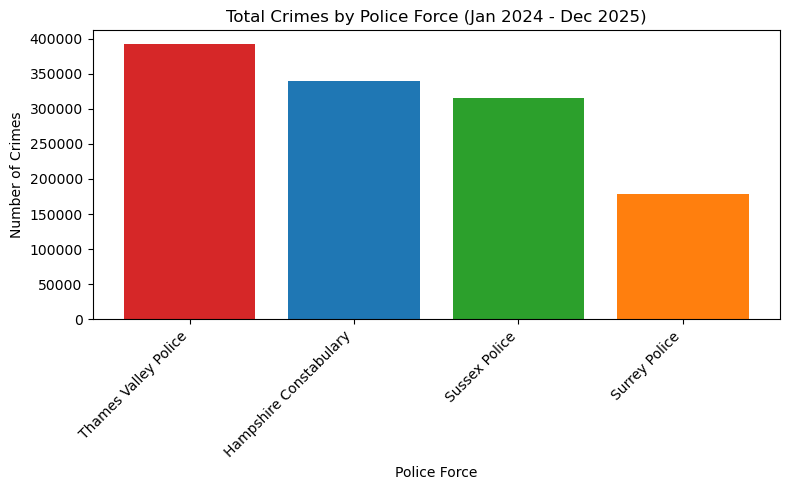

In [43]:
'''Graph 1: Overall Crime

Input: 
- eda_df dataframe
- Falls within_crime column containing police force names

Output:
- Bar chart showing total crime counts for each police force
- Image saved as "overall_crime.png"
'''

crime_by_force = eda_df["Falls within_crime"].value_counts().sort_values(ascending=False)

bar_colours = [force_colours[force] for force in crime_by_force.index]

plt.figure(figsize=(8, 5))
plt.bar(crime_by_force.index, crime_by_force.values, color=bar_colours)
plt.title("Total Crimes by Police Force (Jan 2024 - Dec 2025)")
plt.xlabel("Police Force")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("overall_crime.png", dpi=300, bbox_inches="tight")

plt.show()

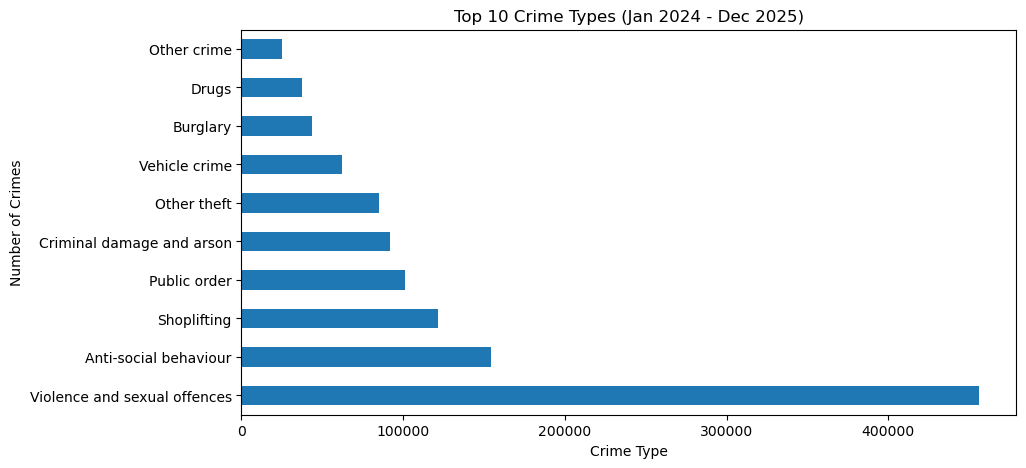

In [28]:
'''Graph 2: Top 10 Crime Types Bar Chart

Input:
- eda_df dataframe
- Crime type column

Output:
- Horizontal bar chart showing the 10 most common crime types
- Image saved as "top_10_crime_types.png"
'''

crime_types = eda_df["Crime type"].value_counts()

crime_types.head(10).plot(kind="barh", figsize=(10,5))
plt.title("Top 10 Crime Types (Jan 2024 - Dec 2025)")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)

plt.savefig("top_10_crime_types.png", dpi=300, bbox_inches="tight")

plt.show()

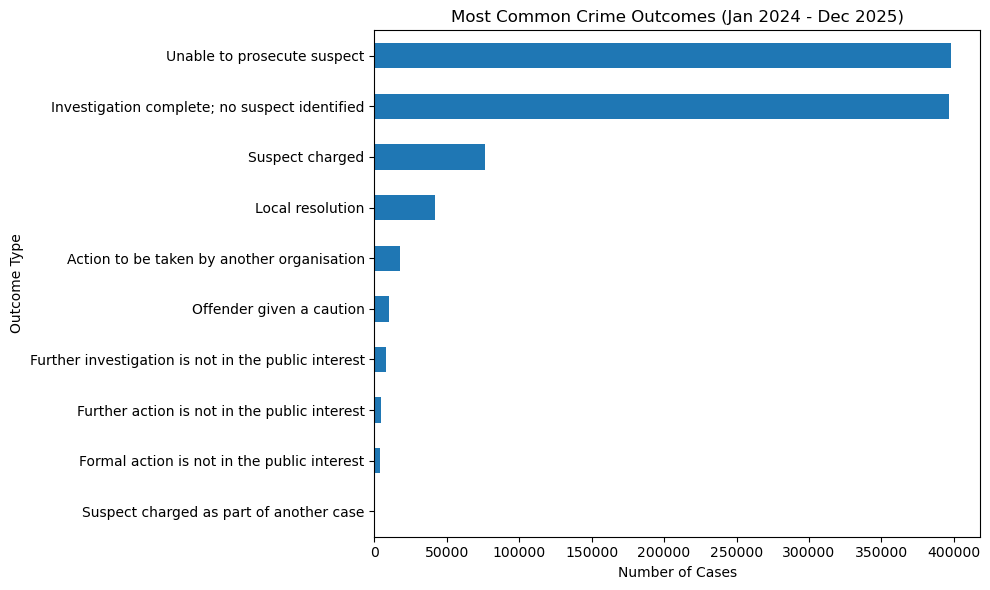

In [29]:
'''Graph 3: Most Common Crime Outcomes

Input:
- eda_df dataframe
- Outcome type column

Output:
- Horizontal bar chart showing the most frequent crime outcomes
- Image saved as "common_outcomes.png"
'''

outcomes = eda_df["Outcome type"].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))

outcomes.sort_values().plot(kind="barh")

plt.title("Most Common Crime Outcomes (Jan 2024 - Dec 2025)")
plt.xlabel("Number of Cases")
plt.ylabel("Outcome Type")
plt.tight_layout()

plt.savefig("common_outcomes.png", dpi=300, bbox_inches="tight")

plt.show()

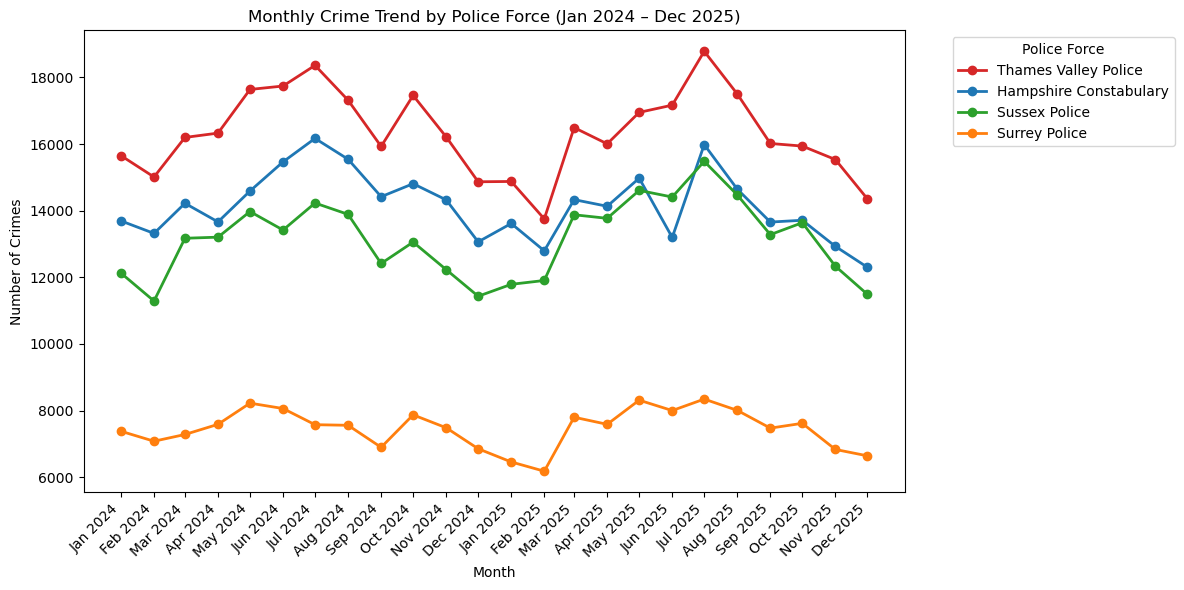

In [30]:
'''Graph 4: Monthly Crime Trend by Police Force

Input: 
- eda_df dataframe
- Month_crime column
- Falls within_crime column

Output:
- Table showing crime count per month by police force
- Table is used to create the monthly crime trend line chart
- Image saved as "monthly_crime_trend_force.png"
'''

monthly_force = (
    eda_df.groupby(["Month_crime", "Falls within_crime"])
    .size()
    .unstack()
    .sort_index()
)

force_order = monthly_force.mean().sort_values(ascending=False).index.tolist()
monthly_force = monthly_force[force_order]

fig, ax = plt.subplots(figsize=(12, 6))

for force in monthly_force.columns:
    ax.plot(
        monthly_force.index,
        monthly_force[force],
        marker="o",
        linewidth=2,
        label=force,
        color=force_colours.get(force, "gray")
    )

ax.set_title("Monthly Crime Trend by Police Force (Jan 2024 – Dec 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Crimes")
ax.set_xticks(monthly_force.index)
ax.set_xticklabels(monthly_force.index.strftime("%b %Y"), rotation=45, ha="right")

plt.legend(title="Police Force", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("monthly_crime_trend_force.png", dpi=300, bbox_inches="tight")

plt.show()

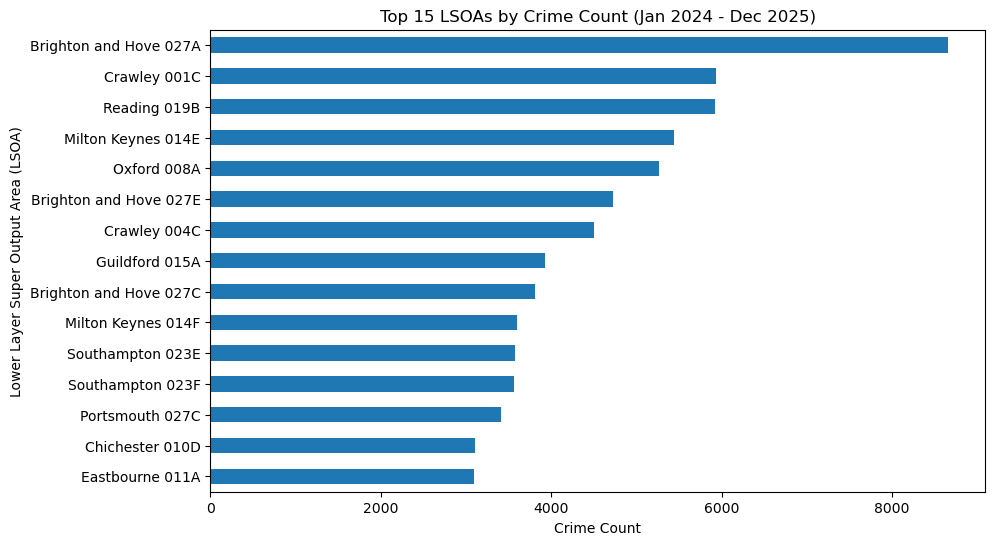

In [32]:
'''Graph 5: Top 15 LSOAs by Crime Count

Input:
- eda_df dataframe
- LSOA name_crime column

Output:
- Bar chart showing Top 15 LSOAs by crime count
- Image of chart saved as "top_15_lsoas_by_crime.png"
'''

top_lsoas = eda_df["LSOA name_crime"].value_counts().head(15)

top_lsoas.plot(kind="barh", figsize=(10,6))
plt.title("Top 15 LSOAs by Crime Count (Jan 2024 - Dec 2025)")
plt.xlabel("Crime Count")
plt.ylabel("Lower Layer Super Output Area (LSOA)")
plt.gca().invert_yaxis()

plt.savefig("top_15_lsoas_by_crime.png", dpi=300, bbox_inches="tight")

plt.show()

In [34]:
'''Preparing Map Data - Crime Points

Input:
- eda_df dataframe
- Latitude_crime
- Longitude_crime
- has_valid_coords_crime

Output:
- GeoDataFrame with geometry points to create the crime location maps
'''

# creating geometry from longitude and latitude
crime_gdf = gpd.GeoDataFrame(
    eda_df[eda_df["has_valid_coords_crime"]].copy(),
    geometry=gpd.points_from_xy(
        eda_df.loc[eda_df["has_valid_coords_crime"], "Longitude_crime"],
        eda_df.loc[eda_df["has_valid_coords_crime"], "Latitude_crime"]
    ),
    crs="EPSG:4326"
).to_crs(epsg=3857)

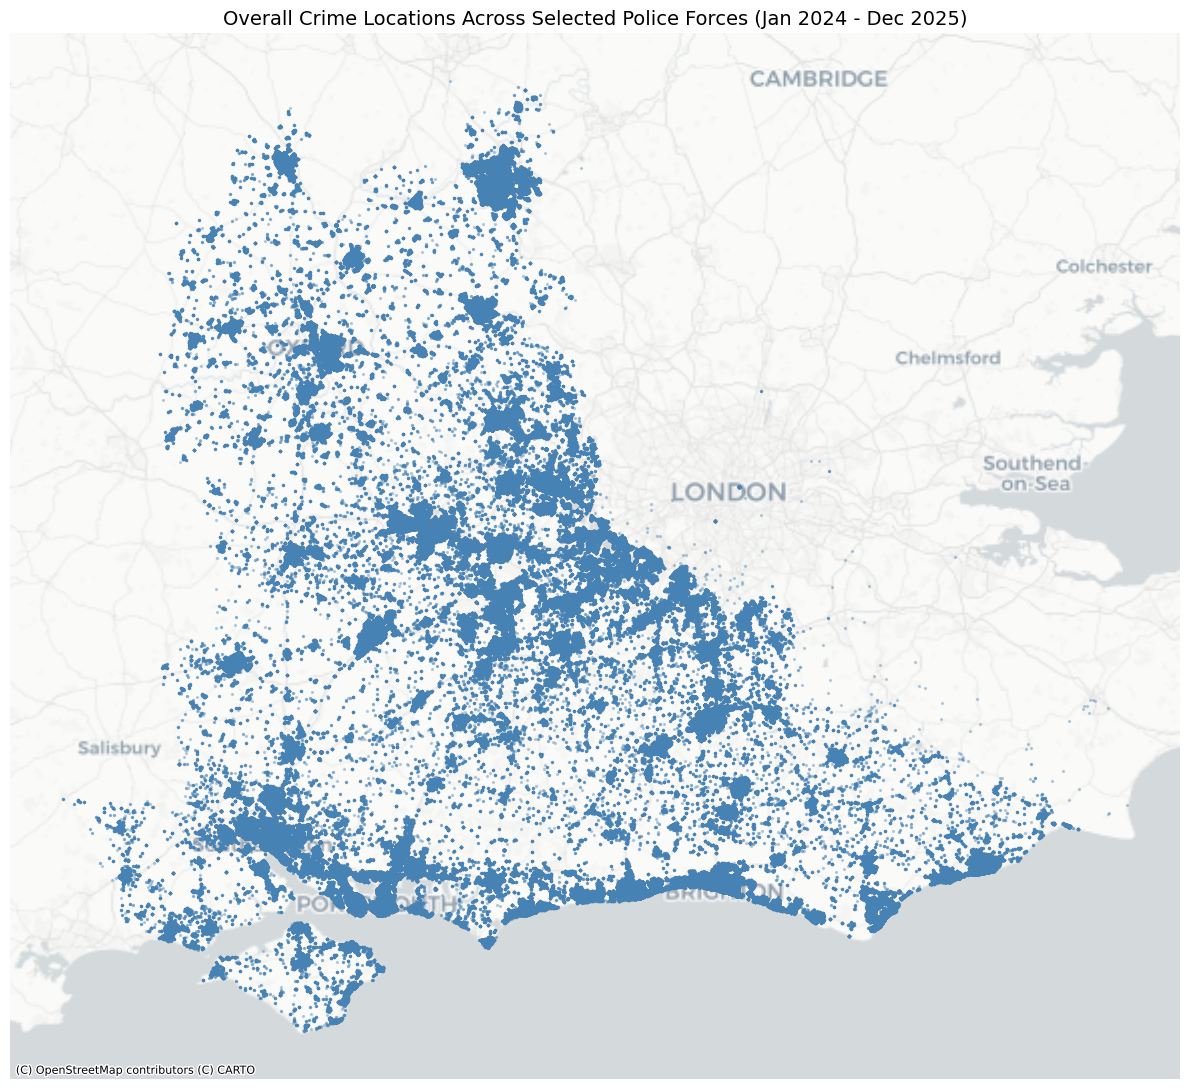

In [35]:
'''Map 1: Overall Crime Locations

Input:
- crime_gdf GeoDataFrame
- Geometry points created from Latitude_crime and Longitude_crime

Output:
- Static map showing spatial distribution of crime locations
- Basemap added for geographic context
- Image saved as "crime_locations_force.png"
'''

fig, ax = plt.subplots(figsize=(12, 12))

# Plot crime points
crime_gdf.plot(
    ax=ax,
    markersize=2,
    alpha=0.3,
    color="steelblue"
)

# Add labelled basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# Add title and clean formatting
ax.set_title("Overall Crime Locations Across Selected Police Forces (Jan 2024 - Dec 2025)", fontsize=14)
ax.set_axis_off()

plt.tight_layout()

plt.savefig("crime_locations_force.png", dpi=300, bbox_inches="tight")

plt.show()

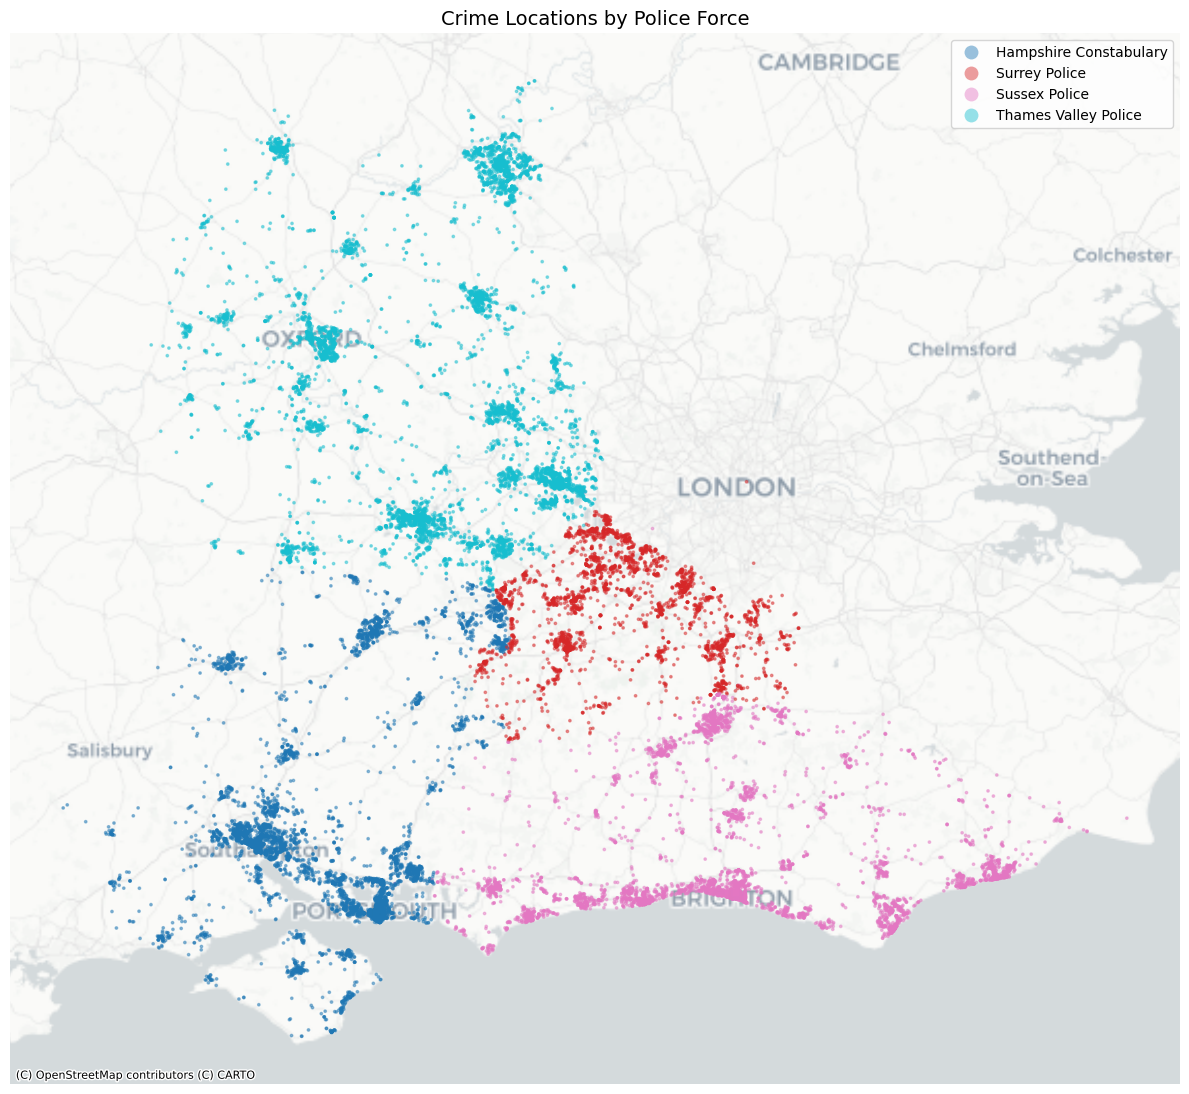

In [36]:
'''Map 2: Crime Locations by Police Force

Input:
- crime_gdf GeoDataFrame
- Falls within_crime column containing police force names

Output:
- Map showing crime locations coloured by police force
- Random sample used to improve map readability
- Image saved as "crime_locations_police_force.png"
'''


force_sample_gdf = crime_gdf.sample(min(20000, len(crime_gdf)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 12))

force_sample_gdf.plot(
    ax=ax,
    column="Falls within_crime",
    categorical=True,
    markersize=3,
    alpha=0.45,
    legend=True
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Crime Locations by Police Force", fontsize=14)
ax.set_axis_off()

plt.tight_layout()

plt.savefig("crime_locations_police_force.png", dpi=300, bbox_inches="tight")

plt.show()

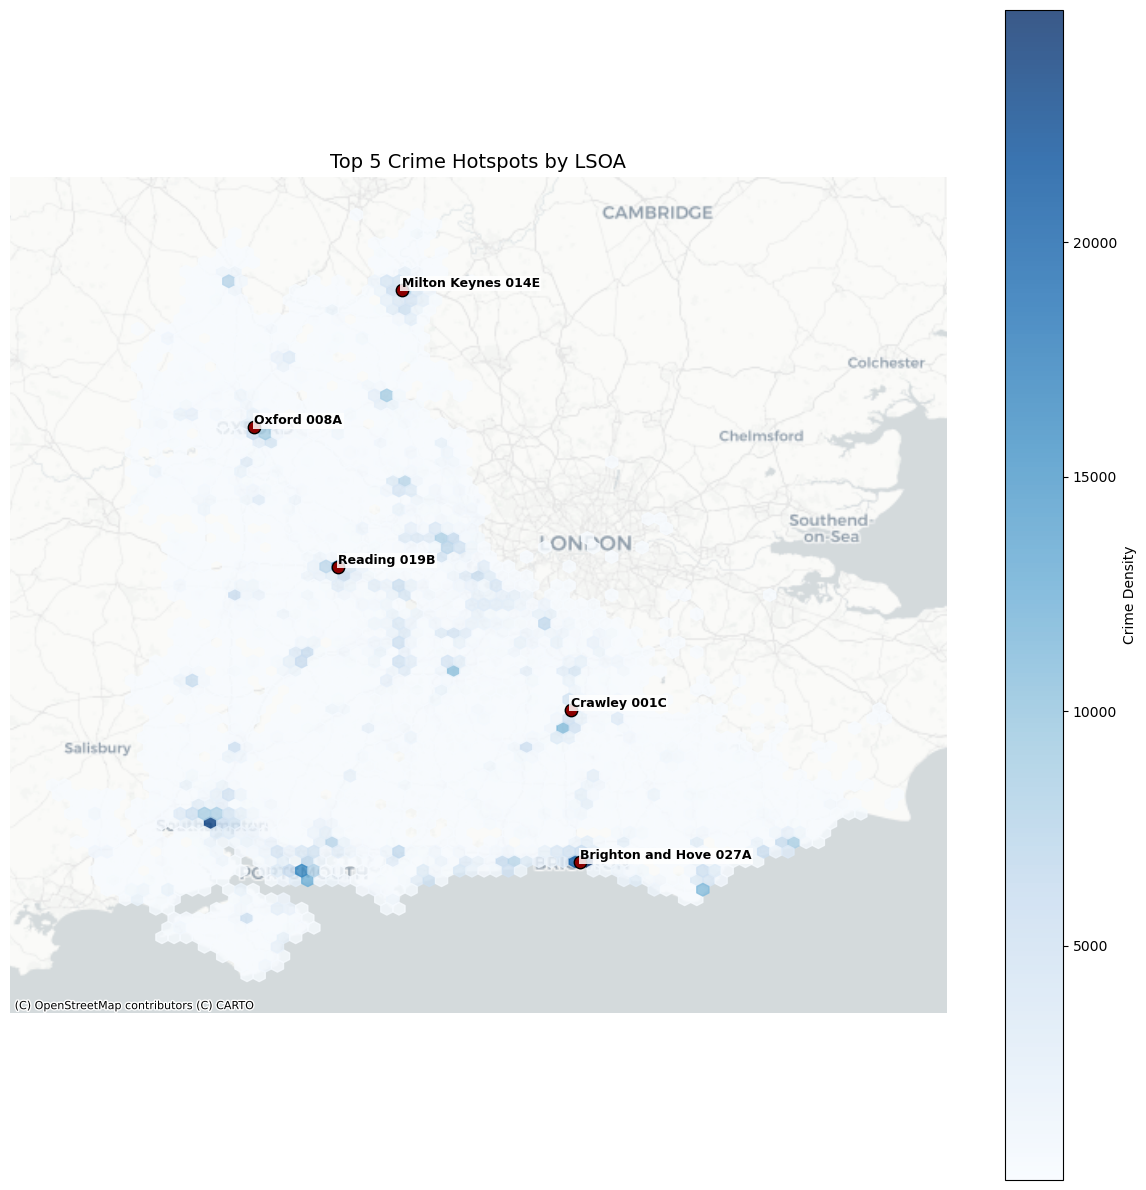

In [37]:
'''Map 3: Top 5 Crime Hotspots by LSOA (Density Map)

Input:
- crime_gdf GeoDataFrame containing crime coordinates
- eda_df dataframe

Output:
- Hexbin density map showing areas with highest crime concentration
- Labels of Top 5 LSOA hotspots
- Image saved as "crime_hotspots_map_lsoa.png"
'''

# Creating hexbin density layer

fig, ax = plt.subplots(figsize=(12, 12))

hb = ax.hexbin(
    crime_gdf.geometry.x,
    crime_gdf.geometry.y,
    gridsize=70,  # controls hex size
    cmap="Blues",
    mincnt=1,
    alpha=0.8
)

# adding colour scale
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Crime Density")

# Adding labelled basemap

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# labelling top LSOA hotspots

top_lsoa_labels = (
    eda_df[
        ["LSOA name_crime",
         "lsoa_crime_count",
         "lsoa_mean_longitude_crime",
         "lsoa_mean_latitude_crime"]
    ]
    .drop_duplicates()
    .nlargest(5, "lsoa_crime_count")
)

# Convert hotspot labels to GeoDataFrame
label_gdf = gpd.GeoDataFrame(
    top_lsoa_labels,
    geometry=gpd.points_from_xy(
        top_lsoa_labels["lsoa_mean_longitude_crime"],
        top_lsoa_labels["lsoa_mean_latitude_crime"]
    ),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Plot hotspot markers
label_gdf.plot(
    ax=ax,
    color="darkred",
    markersize=80,
    edgecolor="black"
)

# Add text labels
for x, y, label in zip(
    label_gdf.geometry.x,
    label_gdf.geometry.y,
    label_gdf["LSOA name_crime"]
):
    ax.text(
        x, y,
        label,
        fontsize=9,
        weight="bold",
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=1)
    )

# Final formatting

ax.set_title("Top 5 Crime Hotspots by LSOA", fontsize=14)
ax.set_axis_off()

plt.tight_layout()

plt.savefig("crime_hotspots_map_lsoa.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
'''Final Summary Table for Decision-Making'''

monthly_force_counts = (
    eda_df.groupby(["Falls within_crime", "Month_crime"])
    .size()
    .reset_index(name="crime_count")
)

force_summary = monthly_force_counts.groupby("Falls within_crime")["crime_count"].agg(
    avg_monthly_crime="mean",
    max_monthly_crime="max",
    min_monthly_crime="min"
).round(1)

top_crime_type_by_force = (
    eda_df.groupby("Falls within_crime")["Crime type"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_frame("most_common_crime_type")
)

top_outcome_by_force = (
    eda_df.groupby("Falls within_crime")["Outcome type"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_frame("most_common_outcome")
)

force_summary = force_summary.merge(top_crime_type_by_force, left_index=True, right_index=True)
force_summary = force_summary.merge(top_outcome_by_force, left_index=True, right_index=True)

force_summary.sort_values("avg_monthly_crime", ascending=False)

,avg_monthly_crime,max_monthly_crime,min_monthly_crime,most_common_crime_type,most_common_outcome
Falls within_crime,,,,,
Thames Valley Police,16336.1,18781,13753,Violence and sexual offences,Unable to prosecute suspect
Hampshire Constabulary,14147.8,16168,12302,Violence and sexual offences,Unable to prosecute suspect
Sussex Police,13145.5,15480,11289,Violence and sexual offences,Investigation complete; no suspect identified
Surrey Police,7464.6,8346,6182,Violence and sexual offences,Unable to prosecute suspect
